In [1]:
%env MUJOCO_GL=egl
import functools
import json
import math
import os
import pathlib
import sys
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.45"

import cv2
import numpy as np
import mediapy as media

from libero.libero import benchmark, get_libero_path
from libero.libero.envs import OffScreenRenderEnv

from openpi.policies import policy_config as _policy_config
from openpi.shared import download
from openpi.training import config as _config

sys.path.append('../py_script')

In [2]:
def _quat2axisangle(quat):
    """
    Copied from robosuite: https://github.com/ARISE-Initiative/robosuite/blob/eafb81f54ffc104f905ee48a16bb15f059176ad3/robosuite/utils/transform_utils.py#L490C1-L512C55
    """
    # clip quaternion
    if quat[3] > 1.0:
        quat[3] = 1.0
    elif quat[3] < -1.0:
        quat[3] = -1.0

    den = np.sqrt(1.0 - quat[3] * quat[3])
    if math.isclose(den, 0.0):
        # This is (close to) a zero degree rotation, immediately return
        return np.zeros(3)

    return (quat[:3] * 2.0 * math.acos(quat[3])) / den

def write_skill_to_frame(frame, current_skill):
    """Render current skill text at the top-right of the agentview frame."""
    skill_text = f"Skill: {current_skill}" if current_skill else "Skill:"

    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.3
    thickness = 1
    margin = 8
    (text_w, text_h), baseline = cv2.getTextSize(skill_text, font, font_scale, thickness)

    x = max(margin, frame.shape[1] - text_w - margin)
    y = margin + text_h

    cv2.rectangle(
        frame,
        (max(0, x - 4), max(0, y - text_h - 4)),
        (min(frame.shape[1] - 1, x + text_w + 4), min(frame.shape[0] - 1, y + baseline + 4)),
        (0, 0, 0),
        -1,
    )
    cv2.putText(frame, skill_text, (x, y), font, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)

    return frame

In [17]:
def skill_prompt(obs, task, scene_plan='', skill='', mode='thinking'):
    """Build observation dict for Pi0Fuse inference.

    The thought prefix must match the training format from cot_simple.json:
      "Instruction: <task>\\n<scene_plan>"
    A 1-element thought list triggers action-mode tokenization (BEGIN_OF_ACTION
    suffix), which prefill() strips before deciding to think or act.
    """
    state_vec = np.concatenate(
        (
            obs["robot0_eef_pos"],
            _quat2axisangle(obs["robot0_eef_quat"]),
            obs["robot0_gripper_qpos"],
        )
    )

    print("current scene plan: ", scene_plan)

    if mode == 'thinking':
        if scene_plan == '':
            thought_prefix = task
        else:
            thought_prefix = scene_plan
        text_input = thought_prefix

    else:
        print(f"Skill: {skill}")
        text_input = skill

    return {
        'observation/image': obs['agentview_image'][::-1, ::-1, :],
        'observation/wrist_image': obs['robot0_eye_in_hand_image'][::-1, ::-1, :],
        "observation/state": state_vec,
        'prompt': task,
        'thought': [text_input],
        'mode': mode,
    }
def invoke_skill_policy(policy, obs, *args, **kwargs):
    prompt = skill_prompt(obs, *args, **kwargs)
    vla_output = policy.infer(prompt)
    return vla_output

def skill_init(policy, obs, task):
    policy.start()
    plan_output = invoke_skill_policy(policy, obs, "Instruction: " + task, mode="thinking")
    scene_plan = plan_output['subtask']
    policy.task = task
    policy.plan = scene_plan

def skill_infer(policy, obs):
    skill_output = invoke_skill_policy(policy, obs, policy.plan, mode="thinking")
    skill = skill_output['subtask']
    act_output = invoke_skill_policy(policy, obs, '', skill=skill, mode="acting")
    return act_output

# Load pi model
def create_pi05_skill(model_name, checkpoint_dir=None, assets_dir=None):
    vla_config = _config.get_config(model_name)
    if checkpoint_dir is None:
        checkpoint_dir = download.maybe_download(f"gs://openpi-assets/checkpoints/{model_name}")
    else:
        checkpoint_dir = pathlib.Path(checkpoint_dir).resolve()

    # Load norm stats from assets dir if checkpoint doesn't have them
    norm_stats = None
    if assets_dir is not None:
        data_config = vla_config.data.create(vla_config.assets_dirs, vla_config.model)
        if data_config.asset_id is not None:
            from openpi.training import checkpoints as _checkpoints
            assets_path = pathlib.Path(assets_dir).resolve()
            norm_stats = _checkpoints.load_norm_stats(assets_path, data_config.asset_id)

    initial_scene_plan = {
        "Plan: TBD.\n"
        " What I have done: TBD.\n"  # Extra space here follows the original dataset formatting...
        "Now I need to do: TBD.\n"
    }
    policy = _policy_config.create_trained_skill_reasoning_policy(
        vla_config,
        checkpoint_dir,
        norm_stats=norm_stats,
        initial_scene_plan=initial_scene_plan,
        sample_kwargs={
            "temperature": 0.0,
            "max_reasoning_steps": 256,
            "force_initial_reasoning": True
        }
    )
    policy.initialize = functools.partial(skill_init, policy)
    policy.run_vla = functools.partial(skill_infer, policy)
    return policy

# model_name = 'pi05_libero_skill_reason_lora_v2'
model_name = 'pi05_libero_skill_reason_fixed'
# Create a trained policy.
policy = create_pi05_skill(   # Use LoRA weights:
    model_name,
    # checkpoint_dir='../pace/openpi/checkpoints/pi05_libero_reason_lora/pi05_libero_reason_lora/7999',
    checkpoint_dir=f'../pace/openpi/checkpoints/{model_name}/{model_name}/29999',
    assets_dir=f'../pace/openpi/assets/{model_name}'
    # 'pi05_libero_10_reason_lora',
    # checkpoint_dir='../pace/openpi/checkpoints/pi05_libero_10_reason_lora/pi05_libero_10_reason_lora/1500',
    # assets_dir='../pace/openpi/assets/pi05_libero_10_reason_lora'
)

In [3]:
# EE control
def vanilla_prompt(obs, task): 
    qpos = np.array(obs['robot0_joint_pos'])
    gripper_pos = np.array([obs['robot0_gripper_qpos'][0]])
    return {
        # Flip the ego camera?
        'observation/image': obs['agentview_image'][::-1, ::-1, :],
        'observation/wrist_image': obs['robot0_eye_in_hand_image'][::-1, ::-1, :],
        "observation/state": np.concatenate(
            (
                obs["robot0_eef_pos"],
                _quat2axisangle(obs["robot0_eef_quat"]),
                obs["robot0_gripper_qpos"],
            )
        ),
        'prompt': task
    }

def vanilla_init(policy, obs, task):
    policy.task = task

def vanilla_infer(policy, obs):
    prompt = vanilla_prompt(obs, policy.task)
    return policy.infer(prompt)

def create_pi05(model_name):
    vla_config = _config.get_config(model_name)
    checkpoint_dir = download.maybe_download(f"gs://openpi-assets/checkpoints/{model_name}")
    policy = _policy_config.create_trained_policy(vla_config, checkpoint_dir)
    policy.initialize = functools.partial(vanilla_init, policy)
    policy.run_vla = functools.partial(vanilla_infer, policy)
    return policy
policy2 = create_pi05("pi05_libero")

In [4]:
def _get_libero_env(task, resolution, seed):
    """Initializes and returns the LIBERO environment, along with the task description."""
    task_description = task.language
    task_bddl_file = pathlib.Path(get_libero_path("bddl_files")) / task.problem_folder / task.bddl_file
    env_args = {"bddl_file_name": task_bddl_file, "camera_heights": resolution, "camera_widths": resolution, "camera_depths": True}
    env = OffScreenRenderEnv(**env_args)
    env.seed(seed)  # IMPORTANT: seed seems to affect object positions even when using fixed initial state
    return env, task_description

class LiberoEnvMaker:
    def __init__(self, suite: str,
                 render_resolution: int = 512, seed: int = 0,
                 repeats: int = 1):
        benchmark_dict = benchmark.get_benchmark_dict()
        self.task_suite = benchmark_dict[suite]()
        self.repeats = repeats
        self.render_resolution = render_resolution
        self.seed = seed

    def get_num_tasks(self):
        return self.task_suite.n_tasks

    def task_instantiations(self, task_id):
        task = self.task_suite.get_task(task_id)
        print(task, task_id)
        initial_states = self.task_suite.get_task_init_states(task_id)
        env, task_description = _get_libero_env(task, self.render_resolution, self.seed)
        for episode_idx in range(self.repeats):
            env.reset()
            obs = env.set_init_state(initial_states[episode_idx])
            yield obs, env, task_description


In [5]:
import mujoco

def add_visual_point(scn, pos, rgba=[1, 0, 0, 1], radius=0.01):
    """Add a sphere marker at a 3D position to an MjvScene.
    
    Args:
    scn: mujoco.MjvScene object (e.g. env.sim._render_context_offscreen.scn)
    pos: [x, y, z] position
    rgba: [r, g, b, a] color
    radius: sphere radius
    """
    if scn.ngeom >= scn.maxgeom:
        print("WARNING: scene buffer full!")
        return  # scene buffer full
    
    mujoco.mjv_initGeom(
        scn.geoms[scn.ngeom],
        type=mujoco.mjtGeom.mjGEOM_SPHERE,
        size=[radius, 0, 0],
        pos=np.array(pos, dtype=np.float64),
        mat=np.eye(3, dtype=np.float64).flatten(),
        rgba=np.array(rgba, dtype=np.float32),
    )
    scn.ngeom += 1

def patch_env_for_render(env):
    """
    Patch the rendering function of a robosuite environment to add the ability to draw 3d points.
    This code was generated by Claude
    """
    # Get the render context
    render_ctx = env.sim._render_context_offscreen
    # Save original render method (unused)
    original_render = env.sim.render

    def render_with_points(*args, visual_points=[], **kwargs):
        env._visual_points = visual_points
        result = original_render(*args, **kwargs)
        env._visual_points = []
        return result
    env.sim.render = render_with_points

    def patched_render(width, height, camera_id=None, segmentation=False):
        """
        Copy of original function, but we needed to break it up.

        visual_points should be a list of dicts: {"pos": [x,y,z], "rgba": [r,g,b,a], "radius": 0.01}
        """
        # Call original up to mjv_updateScene (we need to replicate the logic)
        viewport = mujoco.MjrRect(0, 0, width, height)
        
        if width > render_ctx.con.offWidth or height > render_ctx.con.offHeight:
            new_width = max(width, render_ctx.model.vis.global_.offwidth)
            new_height = max(height, render_ctx.model.vis.global_.offheight)
            render_ctx.update_offscreen_size(new_width, new_height)
        
        if camera_id is not None:
            if camera_id == -1:
                render_ctx.cam.type = mujoco.mjtCamera.mjCAMERA_FREE
            else:
                render_ctx.cam.type = mujoco.mjtCamera.mjCAMERA_FIXED
                render_ctx.cam.fixedcamid = camera_id
        
        mujoco.mjv_updateScene(
            render_ctx.model._model, render_ctx.data._data,
            render_ctx.vopt, render_ctx.pert, render_ctx.cam,
            mujoco.mjtCatBit.mjCAT_ALL, render_ctx.scn
        )
        
        if segmentation:
            render_ctx.scn.flags[mujoco.mjtRndFlag.mjRND_SEGMENT] = 1
            render_ctx.scn.flags[mujoco.mjtRndFlag.mjRND_IDCOLOR] = 1
        
        # --- Add visual points here ---
        for pt in env._visual_points:
            add_visual_point(render_ctx.scn, pt["pos"], pt.get("rgba", [1,0,0,1]), pt.get("radius", 0.01))
        
        mujoco.mjr_render(viewport=viewport, scn=render_ctx.scn, con=render_ctx.con)
        
        if segmentation:
            render_ctx.scn.flags[mujoco.mjtRndFlag.mjRND_SEGMENT] = 0
            render_ctx.scn.flags[mujoco.mjtRndFlag.mjRND_IDCOLOR] = 0

    render_ctx.render = patched_render

def get_cam_pose(env, cam_name="agentview"):
    cam_id = env.sim.model.camera_name2id(cam_name)
    return (env.sim.model.cam_pos[cam_id], env.sim.model.cam_quat[cam_id])
    
def set_cam_pose(env, pose, cam_name="agentview"):
    cam_id = env.sim.model.camera_name2id(cam_name)
    env.sim.model.cam_pos[cam_id] = pose[0]
    env.sim.model.cam_quat[cam_id] = pose[1]

In [34]:
import optax
import flax.nnx as nnx
import jax.numpy as jnp
import jax
#print(policy._model.PaliGemma.llm)

In [35]:
sys.path.append('../datasets')
import importlib
import probe_network
importlib.reload(probe_network)
from probe_network import ProbeNetwork
import orbax.checkpoint as ocp
checkpointer = ocp.StandardCheckpointer()
checkpoint_dir = os.path.abspath('../datasets/checkpoints/state')
probe = ProbeNetwork(nnx.Rngs(0))
graphdef, abstract_state = nnx.split(probe)
state_restored = checkpointer.restore(checkpoint_dir, abstract_state)
probe = nnx.merge(graphdef, state_restored)
probe.eval()

In [26]:
rollout = []
frames = []
wrist_frames = []
explain_frames = []

libero_envs = LiberoEnvMaker('libero_10')

current scene plan:  
inputs -------------------> ['Instruction: pick up the white mug']
mode thinking now...
output scene plan:  1. PICKUP_FROM(white mug, table) 2. PLACE_ON(white mug, table)
current scene plan:  
inputs -------------------> ['1. PICKUP_FROM(white mug, table) 2. PLACE_ON(white mug, table)']
mode thinking now...
output scene plan:  PICKUP_FROM(white mug, table)
current scene plan:  
Skill: PICKUP_FROM(white mug, table)
inputs -------------------> ['PICKUP_FROM(white mug, table)']
mode acting now...
current scene plan:  
inputs -------------------> ['1. PICKUP_FROM(white mug, table) 2. PLACE_ON(white mug, table)']
mode thinking now...
output scene plan:  PICKUP_FROM(white mug, table)
current scene plan:  
Skill: PICKUP_FROM(white mug, table)
inputs -------------------> ['PICKUP_FROM(white mug, table)']
mode acting now...
current scene plan:  
inputs -------------------> ['1. PICKUP_FROM(white mug, table) 2. PLACE_ON(white mug, table)']
mode thinking now...
output scene 

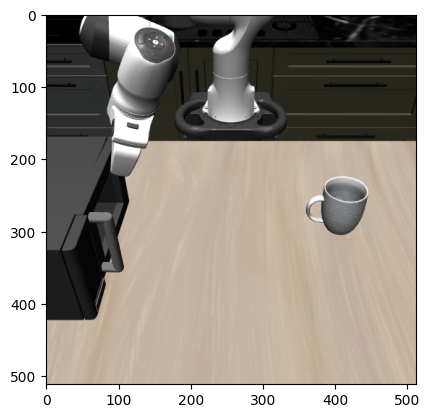

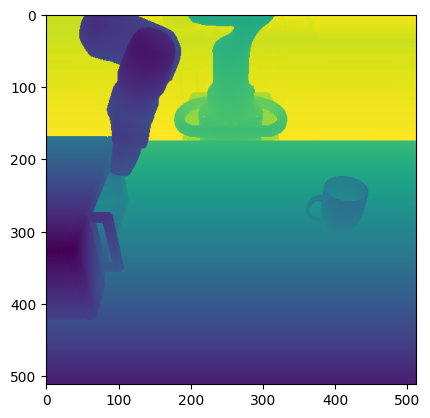

In [30]:
def run(policy, iters=120, init=True, override_task=None, early_exit=True):
    global obs, env
    # STARTUP section
    if init:
        rollout.clear()
        frames.clear()
        wrist_frames.clear()
        instance = next(libero_envs.task_instantiations(9))
        obs, env, task_description = instance
        if override_task is not None:
            task_description = override_task
        patch_env_for_render(env)
        policy.initialize(obs, task_description)
    
    vla_output = policy.run_vla(obs)
    actions = vla_output['actions']
    rollout.append(obs)
    
    trajectory_idx = 0
    for i in range(iters):
        act = np.copy(actions[trajectory_idx])
        obs, reward, done, info = env.step(act)
        rollout.append(obs)
        frame = np.copy(obs['agentview_image'][::-1, ::-1, :])
        frames.append(frame)
        wrist_frames.append(obs['robot0_eye_in_hand_image'][::-1, ::-1, :])
        if done and early_exit:
            break
        trajectory_idx += 1
        if trajectory_idx == (len(actions)//2):
            vla_output = policy.run_vla(obs)
            actions = vla_output['actions']
            trajectory_idx = 0
#run(policy, override_task="pick up the white mug")
# run(policy, iters=300)
policy.initialize(obs, "pick up the white mug")
run(policy, iters=120, init=False, early_exit=False)
# run(policy, iters=120, init=False)

freq = 20
#save_cam_pose = get_cam_pose(env)
img = obs['agentview_image'][::-1, ::-1, :]
import matplotlib.pyplot as plt
plt.figure(0)
plt.clf()
plt.imshow(img)
plt.figure(1)
plt.clf()
plt.imshow(obs['agentview_depth'][::-1, ::-1, :])
plt.show()
media.write_video(f'franka_90.mp4', frames, fps=freq)
media.write_video(f'franka_90_wrist.mp4', wrist_frames, fps=freq)

In [7]:
def run_benchmark(name, policy, setting, repeats=2):
    libero_envs = LiberoEnvMaker(setting, repeats=repeats)
    # STARTUP section
    MAX_STEPS = 600
    count = 0
    success = 0
    out_dir = f'benchmark/{name}'
    os.makedirs(out_dir, exist_ok=True)
    result_summary = {}
    for task_num in range(libero_envs.get_num_tasks()):
        stats = []
        for j, instance in enumerate(libero_envs.task_instantiations(task_num)):
            rollout = []
            frames = []
            wrist_frames = []
            obs, env, task_description = instance
            LIBERO_DUMMY_ACTION = [0.0] * 6 + [-1.0]
            for _ in range(20):
                obs, reward, done, info = env.step(LIBERO_DUMMY_ACTION)
            policy.initialize(obs, task_description)
            rollout.append(obs)
            frames.append(obs['agentview_image'][::-1, ::-1, :])
            wrist_frames.append(obs['robot0_eye_in_hand_image'][::-1, ::-1, :])
            patch_env_for_render(env)
            print(task_description)
            vla_output = policy.run_vla(obs)
            actions = vla_output['actions']
    
            trajectory_idx = 0
            count += 1
            for i in range(MAX_STEPS):
                act = np.copy(actions[trajectory_idx])
                obs, reward, done, info = env.step(act)
                frames.append(obs['agentview_image'][::-1, ::-1, :])
                wrist_frames.append(obs['robot0_eye_in_hand_image'][::-1, ::-1, :])
                if done:
                    break
                trajectory_idx += 1
                if trajectory_idx == (len(actions)//2):
                    vla_output = policy.run_vla(obs)
                    actions = vla_output['actions']
                    trajectory_idx = 0
            print(f"TASK {task_num}: STATUS={done} after {i} steps")
            if done:
                success += 1
            freq = 20
            media.write_video(f'{out_dir}/{task_num}.{j}.mp4', frames, fps=freq)
            media.write_video(f'{out_dir}/{task_num}.{j}_wrist.mp4', wrist_frames, fps=freq)
            stats.append({
                "done": bool(done),
                "length": i
            })
        result_summary[task_description] = stats
    print(f"Overall: {success}/{count}")
    with open(f'{out_dir}/summary.json', 'w') as outfile:
        json.dump(result_summary, outfile)
        
    for task, stats in result_summary.items():
        count = len(stats)
        success = 0
        for stat in stats:
            if stat['done']:
                success += 1
        print(f"{task}: {success}/{count}")
    return result_summary

In [ ]:
run_benchmark("pi05", policy2, "libero_10", repeats=10)

In [ ]:
run_benchmark("pi05_skill", policy, "libero_10", repeats=10)

In [59]:
rollout = []
frames = []
wrist_frames = []
explain_frames = []

libero_envs = LiberoEnvMaker('libero_10')

In [61]:
# STARTUP section
def test_steer(run_name, target_pos, task_num, iters=120):
    out_dir = f'benchmark/{run_name}'
    os.makedirs(out_dir, exist_ok=True)
    for instance_idx, instance in enumerate(libero_envs.task_instantiations(task_num)):
        rollout = []
        frames = []
        wrist_frames = []
        explain_frames = []

        obs, env, task_description = instance
        patch_env_for_render(env)
        policy.start()
        print(task_description)
        prompt = skill_prompt(obs, f"Instruction: {task_description}", mode='thinking')
        vla_output = policy.infer(prompt)
        #scene_plan = vla_output['subtask']
        #print(scene_plan)
        # scene_plan = '1. PICKUP_FROM(bowl, table) 2. PLACE_IN(bowl, bottom drawer) 3. CLOSE(bottom drawer)'
        scene_plan = '1. PICKUP_FROM(white mug on the left, table)'
        prompt = skill_prompt(obs, scene_plan, mode='thinking')
        vla_output = policy.infer(prompt)
        skill = vla_output['subtask']
        
        PROBE_LAYER=9
        last_intermediates = jnp.mean(policy.saved_intermediates[0][None, [PROBE_LAYER], 0, -20:, :], axis=2)
        pred_transform = probe(last_intermediates)[0]
        points = [
            {'pos': pred_transform + obs['robot0_eef_pos'], 'rgba': [1,0,0,1], 'radius': 0.02},
        ]
        
        # batch(probe), layer, batch(openpi), token, dim
        
        #task_description = "Place the bowl into the top drawer."
        # prev_pos, prev_quat = save_cam_pose
        # set_cam_pose(env, (prev_pos+[0, 0, 1], prev_quat))
        # obs, reward, done, info = env.step(np.zeros(7))
        # break
        #skill = 'PICK(bowl)'
        #scene_plan = ''
        #scene_plan = 'Plan: 1. Open the top drawer. \
        #What have I done: Open the top drawer. \
        #Now I need to do: Nothing. Task complete.'
        #prompt = prompt_from_obs(obs, task_description, skill=skill, mode='acting')
        prompt = skill_prompt(obs, '', skill=skill, mode='acting')
        vla_output = policy.infer(prompt)
        actions = vla_output['actions']
        subtask = vla_output.get('subtask', None)
        rollout.append(obs)
        
        persistent_bias = jnp.zeros(2048, dtype=last_intermediates.dtype)
        
        trajectory_idx = 0
        for i in range(iters):
            act = np.copy(actions[trajectory_idx])
            obs, reward, done, info = env.step(act)
            rollout.append(obs)
            frame = np.copy(obs['agentview_image'][::-1, ::-1, :])
            frames.append(write_skill_to_frame(frame, skill))
            wrist_frames.append(obs['robot0_eye_in_hand_image'][::-1, ::-1, :])
            if done:
                break
            trajectory_idx += 1
            if trajectory_idx == (len(actions)//2):
                prompt = skill_prompt(obs, scene_plan, mode='thinking')
                bias = jnp.zeros((18, 2048), dtype=last_intermediates.dtype)
                # bias = bias.at[9].set(persistent_bias)
                vla_output = policy.infer(prompt, bias=bias)
                skill = vla_output['subtask']
                last_intermediates = jnp.mean(policy.saved_intermediates[0][None, [PROBE_LAYER], 0, -20:, :], axis=2)
                pred_transform = probe(last_intermediates)[0]
                if target_pos is not None:
                    target = target_pos - obs['robot0_eef_pos']
            
                    # https://optax.readthedocs.io/en/latest/getting_started.html
                    start_learning_rate = 1e-3
                    optimizer = optax.adam(start_learning_rate)
                    params = jnp.zeros_like(last_intermediates)
                    opt_state = optimizer.init(params)
                    def compute_loss(params):
                        # bias = jnp.zeros((18, 2048), dtype=last_intermediates.dtype)
                        # bias = bias.at[0].set(params)
                        # vla_output = policy.infer(prompt, bias=bias) # Get rid of batch dimension
                        # intermediates = jnp.mean(policy.saved_intermediates[0][None, [9], 0, -20:, :], axis=2)
                        # pred = probe(intermediates)[0]
                        # return jnp.mean((pred - target)**2) + 0.1*jnp.mean(params**2)
                        pred = probe(params + last_intermediates)[0]
                        return jnp.mean((pred - target)**2) + 0.01*jnp.mean(params**2)
                    for j in range(30):
                        grads = jax.grad(compute_loss)(params)
                        updates, opt_state = optimizer.update(grads, opt_state)
                        params = optax.apply_updates(params, updates)
                    persistent_bias = params[0, 0]
        
                prompt = skill_prompt(obs, '', skill=skill, mode='acting')
                bias = jnp.zeros((18, 2048), dtype=last_intermediates.dtype)
                bias = bias.at[PROBE_LAYER].set(persistent_bias)
                vla_output = policy.infer(prompt, bias=bias) # Get rid of batch dimension
                # First element is the reasoning side output
                # (Add batch dimension, take all layers, remove old batch dimension, take last token, take full embedding)[remove batch dimension]
                actions = vla_output['actions']
                points = [
                    {'pos': pred_transform + obs['robot0_eef_pos'], 'rgba': [1,0,0,1],'radius': 0.02},
                ]
                if target_pos is not None:
                    last_intermediates = jnp.mean(policy.saved_intermediates[0][None, [PROBE_LAYER], 0, -20:, :], axis=2)
                    pred_transform2 = probe(last_intermediates)[0]
                    points.append(
                        {'pos': pred_transform2 + obs['robot0_eef_pos'], 'rgba': [0,0,1,1], 'radius': 0.02}
                    )
                trajectory_idx = 0
            explain_img = np.copy(env.sim.render(width=512, height=512, camera_name="agentview", visual_points=points)[::-1, ::-1, :])
            explain_frames.append(write_skill_to_frame(explain_img, skill))
        media.write_image(f'{out_dir}/{task_num}.{instance_idx}_steer.png', frames[-1])
        media.write_video(f'{out_dir}/{task_num}.{instance_idx}_steer.mp4', frames, fps=freq)
        media.write_video(f'{out_dir}/{task_num}.{instance_idx}_steer_wrist.mp4', wrist_frames, fps=freq)
        media.write_video(f'{out_dir}/{task_num}.{instance_idx}_steer_explain.mp4', explain_frames, fps=freq)


# target_pos = jnp.array([-0.00779673,  0.22186068,  1.1129], dtype=jnp.float32) # top drawer, task 3 libero_10
target_pos = jnp.array([-0.05, -0.30033966,  0.94732314], dtype=jnp.float32) # white mug, task 9 libero_10
test_steer("pi05_skill_steer", target_pos, 9)

In [ ]:
instance = next(libero_envs.task_instantiations(0))
obs, env, task_description = instance
patch_env_for_render(env)

points = [{'pos': obs['robot0_eef_pos']}]
img = env.sim.render(width=512, height=512, camera_name="agentview", visual_points=points)[::-1, ::-1, :]
plt.figure(0)
plt.clf()
plt.imshow(img)

In [ ]:
#frames = []
#wrist_frames = []
#instance = next(libero_envs.task_instantiations(0))
#obs, env, task_description = instance

trajectory_idx = 0
for i in range(50):
    act = [0, 0.1, 0, 0, 0, 0, 0]
    obs, reward, done, info = env.step(act)
    frames.append(obs['agentview_image'][::-1, ::-1, :])
    wrist_frames.append(obs['robot0_eye_in_hand_image'][::-1, ::-1, :])

freq = 20
#save_cam_pose = get_cam_pose(env)
print(task_description)
img = obs['agentview_image'][::-1, ::-1, :]
import matplotlib.pyplot as plt
plt.figure(0)
plt.clf()
plt.imshow(img)
plt.figure(1)
plt.clf()
plt.imshow(obs['agentview_depth'][::-1, ::-1, :])
plt.show()
media.write_video(f'franka_90.mp4', frames, fps=freq)
media.write_video(f'franka_90_wrist.mp4', wrist_frames, fps=freq)

In [ ]:
instance = next(libero_envs.task_instantiations(0))
obs, env, task_description = instance
policy.start()